# Tahap 2: Eksperimen Model Random Forest
Notebook ini melatih algoritma **Random Forest Classifier** menggunakan dataset final yang sudah melalui tahap pembersihan data, *feature engineering*, dan penyeimbangan kelas (*SMOTE balancing*) yang diambil dari folder `data/processed/`.

Tujuan notebook ini adalah melatih model agar sangat sensitif dalam mendeteksi *Faltering Growth* (gejala awal stunting), mengevaluasi akurasinya, lalu menyimpannya ke **MLflow** agar siap digunakan pada Aplikasi Web.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import warnings


warnings.filterwarnings('ignore')

### 1. Load Dataset

In [22]:
data_path = '../data/processed/dataset_final_training.csv'
df = pd.read_csv(data_path)
print(f"Total data latih: {len(df)} baris")
df.head(3)

Total data latih: 142 baris


,Umur (Bulan),Jenis Kelamin,BB_Awal,TB_Awal,BB_Akhir,TB_Akhir,Lama_Pantau_Bulan,Kecepatan_Tumbuh_BB,Kecepatan_Tumbuh_TB,Rasio_BB_TB_Akhir,Status
0,11,0,5.869504,64.680891,5.946443,64.833711,3,0.03847,0.07641,0.091906,1
1,49,1,15.000000,102.000000,15.000000,102.000000,5,0.00000,0.00000,0.147057,0
2,26,1,8.300000,79.100000,9.300000,79.100000,5,0.25000,0.00000,0.117571,1


### 2. Pisahkan Fitur dan Target

In [23]:
target_col = 'Status'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah Data Training:", len(X_train))
print("Jumlah Data Testing:", len(X_test))

Jumlah Data Training: 113
Jumlah Data Testing: 29


### 3. Set MLflow Experiment

In [24]:
mlflow.set_tracking_uri("file:../mlruns")
mlflow.set_experiment("Stunting_Model_Experiment")

<Experiment: artifact_location=('file:d:/Pijak/Projek Capstone/Main '
 'Project/ML/notebooks/../mlruns/569065162946818888'), creation_time=1780119728343, experiment_id='569065162946818888', last_update_time=1780119728343, lifecycle_stage='active', name='Stunting_Model_Experiment', tags={}, trace_location=None, workspace='default'>

### 4. Training Model Random Forest

In [25]:
rf_params = {
    'n_estimators': 150,
    'max_depth': 12,
    'random_state': 42,
    'class_weight': 'balanced'
}

with mlflow.start_run(run_name="RF_Dynamic_Features") as run:
    mlflow.log_params(rf_params)
    
    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(model, "dynamic_rf_model")
    
    print(f"--- Pelatihan Selesai! ---")
    print(f"Akurasi Model Dinamis: {acc * 100:.2f}%")
    print(f"Run ID MLflow: {run.info.run_id}")

2026/06/01 13:27:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/01 13:27:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- Pelatihan Selesai! ---
Akurasi Model Dinamis: 93.10%
Run ID MLflow: 9b21a31f0522438587bc51250a570d20


### 5. Evaluasi & Feature Importance

In [26]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Tampilkan Feature Importance
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(feat_imp)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.88      1.00      0.93        14

    accuracy                           0.93        29
   macro avg       0.94      0.93      0.93        29
weighted avg       0.94      0.93      0.93        29


Feature Importances:
Kecepatan_Tumbuh_TB    0.248683
Kecepatan_Tumbuh_BB    0.197605
Rasio_BB_TB_Akhir      0.170727
BB_Akhir               0.100325
Umur (Bulan)           0.099008
TB_Awal                0.059745
BB_Awal                0.055625
TB_Akhir               0.044352
Lama_Pantau_Bulan      0.020186
Jenis Kelamin          0.003744
dtype: float64


### 6. Visualisasi Evaluasi (Confusion Matrix Heatmap)
Mengevaluasi di mana posisi model paling sering benar dan di mana model mengalami kebingungan (salah tebak).

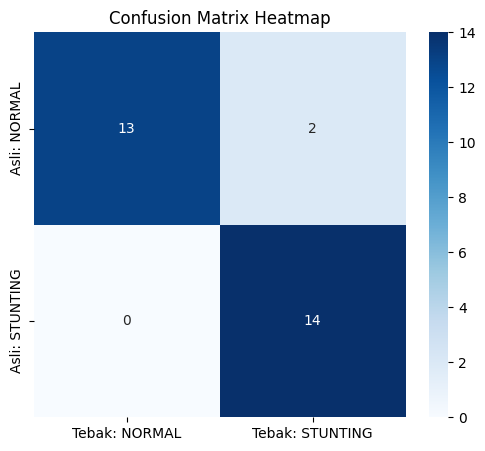

In [27]:
# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi dengan Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tebak: NORMAL', 'Tebak: STUNTING'], 
            yticklabels=['Asli: NORMAL', 'Asli: STUNTING'])

plt.title('Confusion Matrix Heatmap')
plt.show()
